<a href="https://colab.research.google.com/github/sharrenepf/Tugas-PCVK_Sharren/blob/main/Week7_24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 Segmentasi Citra dengan Thresholding
**Pengolahan Citra dan Visi Komputer Jurusan Teknologi Informasi (POLINEMA)**

| | |
|---|---|
| Nama | *(Sharren Elvareta)* |
| NIM / Kelas | *(244107020191 / TI-3G)* |

**Isi notebook**

- **D1. Tugas Individu** nomor 1 sampai 7 (setup, global threshold manual, adaptive threshold manual, Otsu manual, region growing, segmentasi warna KTP)
- **D2. Tugas Kelompok** perbandingan OCR (pytesseract) pada KTP berwarna, Otsu, dan Adaptive

# D1. TUGAS INDIVIDU
## Nomor 1 Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [45]:
!pip install -q nbconvert[webpdf] playwright
!playwright install --with-deps chromium
!jupyter nbconvert --to webpdf --allow-chromium-download "/content/drive/MyDrive/Colab Notebooks/Week7_24.ipynb"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 623.8/623.8 kB 32.0 MB/s eta 0:00:00
Installing dependencies...
Hit:1 http://archive.ubuntu.com/ubuntu noble InRelease
Get:2 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease
Hit:5 https://cli.github.com/packages stable InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu noble InRelease
Get:7 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Get:9 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Packages [1,545 kB]
Get:10 http://security.ubuntu.com/ubuntu noble-security/main amd64 Packages [1,324 kB]
Fetched 3,247 kB in 1s (2,184 kB/s)
Reading package lists... Done
W: Skipping acquire of config

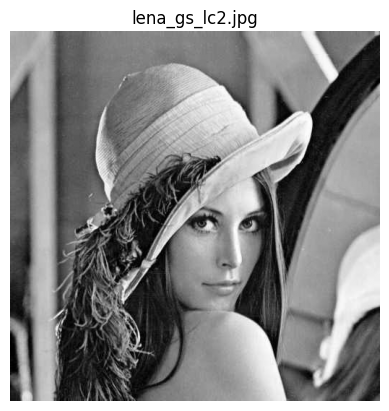

Rentang intensitas: 0 - 255


In [23]:
import cv2 as cv
import os
import matplotlib.pyplot as plt

BASE = '/content/drive/MyDrive/PCVK IMAGES'

# Baca lena.jpg lalu ubah ke grayscale
img = cv.imread(os.path.join(BASE, 'lena.jpg'))
if img is None:
    raise FileNotFoundError('lena.jpg tidak ditemukan di ' + BASE)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Simpan sebagai lena_gs_lc2.jpg
cv.imwrite(os.path.join(BASE, 'lena_gs_lc2.jpg'), gray)

# Tampilkan
plt.imshow(gray, cmap='gray', vmin=0, vmax=255)
plt.title('lena_gs_lc2.jpg'); plt.axis('off'); plt.show()
print('Rentang intensitas:', gray.min(), '-', gray.max())

## Nomor 2 Import Library

In [4]:
#Library yang digunakan
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
from scipy import ndimage as ndi
from skimage import data, filters, color, segmentation, feature, morphology
from skimage.filters import gaussian
from skimage.segmentation import flood

import os
from sklearn.cluster import KMeans

In [5]:
BASE = '/content/drive/MyDrive/PCVK IMAGES'

def img_path(name):
    return os.path.join(BASE, name)

def load_image(name, flag=cv.IMREAD_COLOR):
    """Baca gambar dari folder PCVK IMAGES. flag=0 -> grayscale."""
    img = cv.imread(img_path(name), flag)
    if img is None:
        isi = os.listdir(BASE) if os.path.isdir(BASE) else '(folder tidak ditemukan)'
        raise FileNotFoundError(f"Gambar '{name}' tidak ditemukan di {BASE}\nIsi folder: {isi}")
    return img

print('Isi folder PCVK IMAGES:')
print(os.listdir(BASE) if os.path.isdir(BASE) else 'FOLDER TIDAK DITEMUKAN - cek nama folder & mount Drive')

Isi folder PCVK IMAGES:
['244107020191', 'galaxy.jpg', 'noises', 'djawatan.jpg', 'mandrill.tiff', 'lena.jpg', 'djawatan_night_filter.jpg', 'djawatan_cartoon.jpg', 'sudoku-original.jpg', 'ktp_fulan.jpg', 'ktp_fulani.jpg', 'jungle.png', 'lily.jpg', 'lena_gs.jpg', 'lena_gs_lc2.jpg']


## Nomor 3 Global Threshold Manual

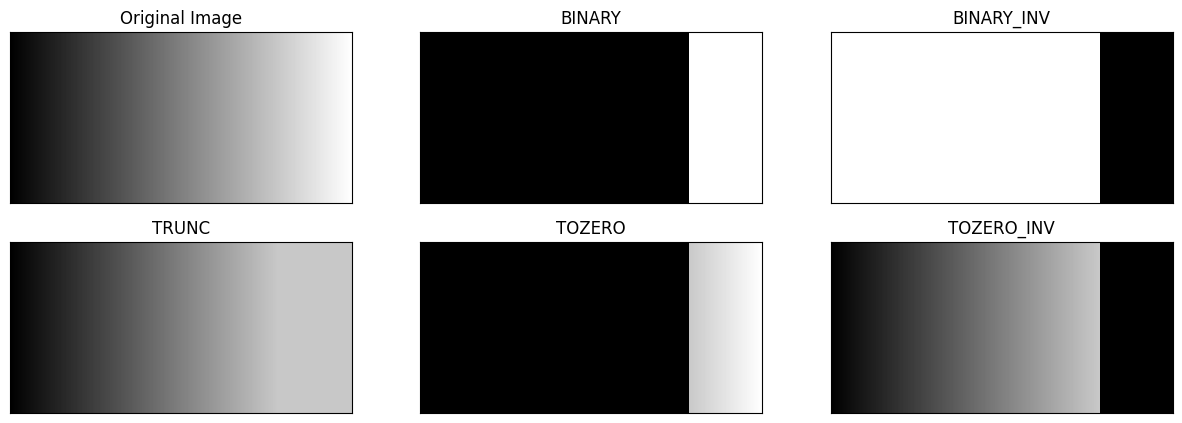

In [7]:
def global_threshold_manual(img, thresh, maxval, jenis):
    # Dikonversi ke int16 agar tidak terjadi overflow uint8
    src = img.astype(np.int16)
    atas = src > thresh                      # True jika piksel > thresh

    if jenis == 'BINARY':
        dst = np.where(atas, maxval, 0)
    elif jenis == 'BINARY_INV':
        dst = np.where(atas, 0, maxval)
    elif jenis == 'TRUNC':
        dst = np.where(atas, thresh, src)
    elif jenis == 'TOZERO':
        dst = np.where(atas, src, 0)
    elif jenis == 'TOZERO_INV':
        dst = np.where(atas, 0, src)
    else:
        raise ValueError('Jenis threshold tidak dikenal')
    return dst.astype(np.uint8)


img = load_image('gradient.jpg', 0)          # grayscale
thresh = 200
maxval = 255

jenis_list = ['BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
hasil = [global_threshold_manual(img, thresh, maxval, j) for j in jenis_list]

titles = ['Original Image'] + jenis_list
images = [img] + hasil

plt.figure(figsize=(15,5))
for i in range(len(images)):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], 'gray', vmin=0, vmax=255, interpolation='nearest')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()

## Nomor 4 Adaptive Threshold Manual

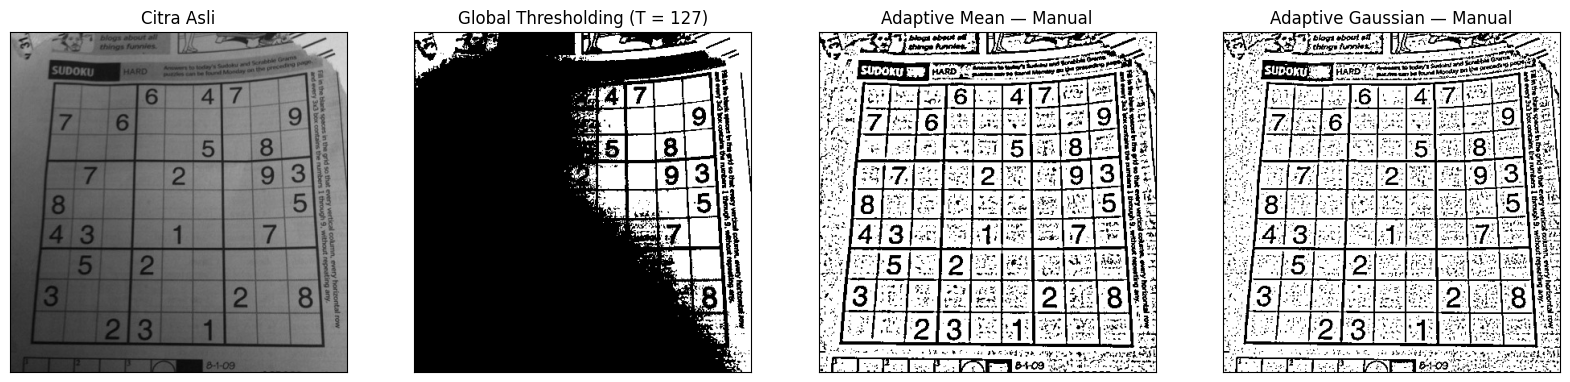

In [8]:
def kernel_mean(b):
    return np.ones(b, dtype=np.float64) / b

def kernel_gaussian(b, sigma):
    r = b // 2
    x = np.arange(-r, r+1, dtype=np.float64)
    g = np.exp(-(x**2) / (2 * sigma**2))
    return g / g.sum()                      # dinormalisasi: jumlah bobot = 1

def local_average(gray, kernel):
    """Rata-rata lokal dengan kernel separable (tanpa fungsi filter siap pakai)."""
    r = len(kernel) // 2
    H, W = gray.shape
    p = np.pad(gray.astype(np.float64), r, mode='edge')   # padding tepi

    # 1) lewat arah horizontal
    tmp = np.zeros((H + 2*r, W))
    for k, w in enumerate(kernel):
        tmp += w * p[:, k:k+W]

    # 2) lewat arah vertikal
    out = np.zeros((H, W))
    for k, w in enumerate(kernel):
        out += w * tmp[k:k+H, :]
    return out

def adaptive_threshold_manual(gray, b=11, C=2, metode='mean', sigma=2):
    kern = kernel_mean(b) if metode == 'mean' else kernel_gaussian(b, sigma)
    T = local_average(gray, kern) - C                    # T(x,y) = rata-rata - C
    return np.where(gray > T, 255, 0).astype(np.uint8)


gray = load_image('sudoku-original.jpg', 0)

thresh = 127
th_global = np.where(gray > thresh, 255, 0).astype(np.uint8)          # global manual
th_mean   = adaptive_threshold_manual(gray, b=11, C=2, metode='mean')
th_gauss  = adaptive_threshold_manual(gray, b=11, C=2, metode='gaussian', sigma=2)

titles = ['Citra Asli', 'Global Thresholding (T = 127)', 'Adaptive Mean — Manual', 'Adaptive Gaussian — Manual']
citra2 = [gray, th_global, th_mean, th_gauss]

plt.figure(figsize=(20,6))
for i in range(len(citra2)):
    plt.subplot(1,4,i+1)
    plt.imshow(citra2[i], 'gray', vmin=0, vmax=255)
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()

## Nomor 5A Otsu Thresholding Manual

Threshold Otsu manual   : 114
Threshold Otsu library  : 113.0
Hasil manual == library?: True


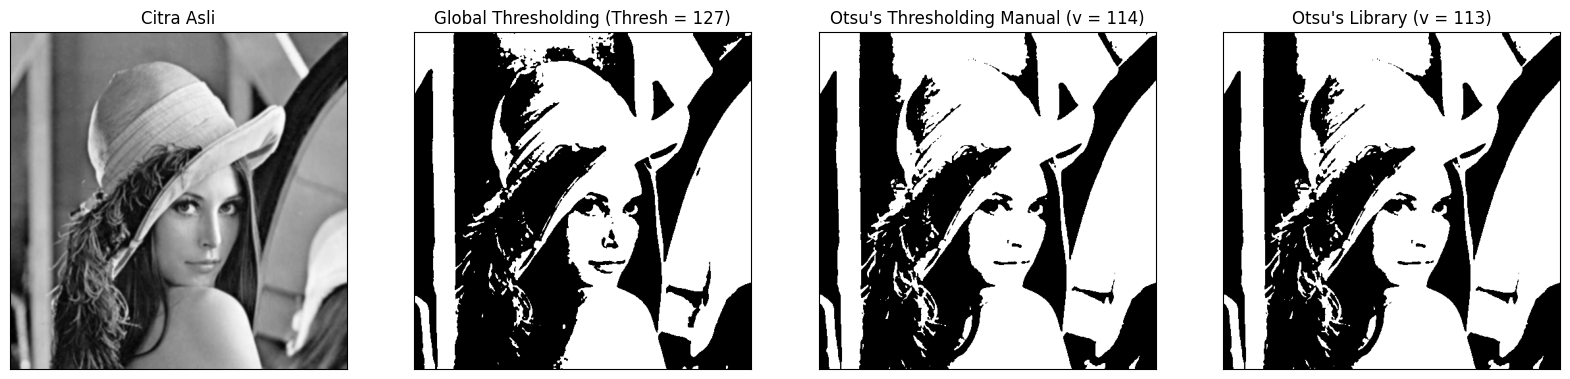

In [24]:
def otsu(gray):
    # Histogram & probabilitas tiap level 0..255
    his = np.bincount(gray.ravel(), minlength=256).astype(np.float64)
    p = his / his.sum()
    intensity_arr = np.arange(256)

    final_thresh = -1
    final_value = -1

    for t in range(1, 256):
        Wb = p[:t].sum()                      # bobot background
        Wf = p[t:].sum()                      # bobot foreground
        if Wb == 0 or Wf == 0:                # kelas kosong -> lewati
            continue

        mub = (intensity_arr[:t] * p[:t]).sum() / Wb      # mean background
        muf = (intensity_arr[t:] * p[t:]).sum() / Wf      # mean foreground
        value = Wb * Wf * (mub - muf) ** 2                # between-class variance

        if value > final_value:
            final_thresh = t
            final_value = value

    final_img = np.where(gray >= final_thresh, 255, 0).astype(np.uint8)
    return final_img, final_thresh


img = load_image('lena_gs_lc2.jpg', 0)
blur = cv.GaussianBlur(img, (5,5), 0)
thresh = 127

otsu_biner, otsu_thresh = otsu(blur)
print('Threshold Otsu manual   :', otsu_thresh)

ret, th1 = cv.threshold(blur, thresh, 255, cv.THRESH_BINARY)                       # global 127
ret2, th_lib = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)       # Otsu library
print('Threshold Otsu library  :', ret2)
print('Hasil manual == library?:', np.array_equal(otsu_biner, th_lib))

x = "Otsu's Thresholding Manual (v = " + str(otsu_thresh) + ")"
titles = ['Citra Asli', 'Global Thresholding (Thresh = ' + str(thresh) + ')', x, "Otsu's Library (v = " + str(int(ret2)) + ")"]
citra3 = [blur, th1, otsu_biner, th_lib]

plt.figure(figsize=(20,6))
for i in range(len(citra3)):
    plt.subplot(1,4,i+1)
    plt.imshow(citra3[i], 'gray', vmin=0, vmax=255)
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()

Rentang intensitas citra Lena (low contrast): 1 - 253
Jumlah piksel dengan nilai > 127 : 132768


/tmp/ipykernel_4309/3684465585.py:7: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(blur.ravel(), 256, [0,256], color='steelblue')


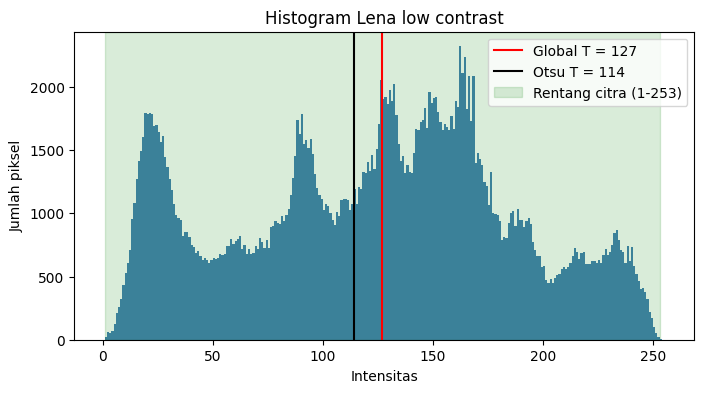

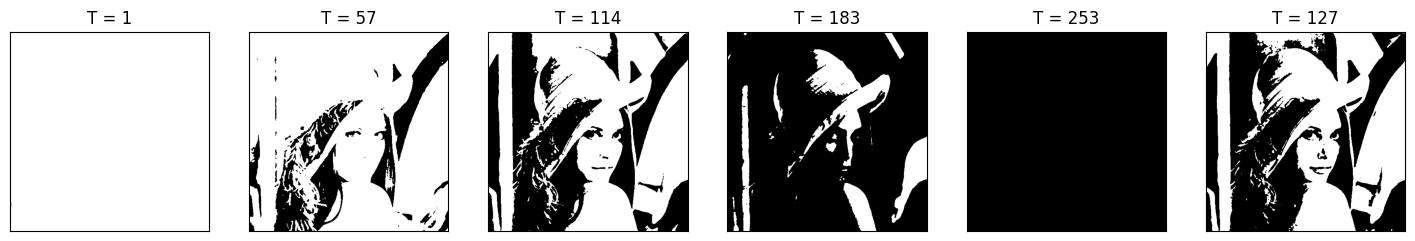

In [25]:
lo, hi = int(blur.min()), int(blur.max())
print(f'Rentang intensitas citra Lena (low contrast): {lo} - {hi}')
print(f'Jumlah piksel dengan nilai > 127 : {(blur > 127).sum()}')

# --- Histogram + garis threshold
plt.figure(figsize=(8,4))
plt.hist(blur.ravel(), 256, [0,256], color='steelblue')
plt.axvline(127, color='red',   label='Global T = 127')
plt.axvline(otsu_thresh, color='black', label=f'Otsu T = {otsu_thresh}')
plt.axvspan(lo, hi, color='green', alpha=0.15, label=f'Rentang citra ({lo}-{hi})')
plt.title('Histogram Lena low contrast'); plt.xlabel('Intensitas'); plt.ylabel('Jumlah piksel')
plt.legend(); plt.show()

# --- Coba beberapa nilai threshold
kandidat = [lo, (lo+otsu_thresh)//2, otsu_thresh, (otsu_thresh+hi)//2, hi, 127]
plt.figure(figsize=(18,3.5))
for i, T in enumerate(kandidat):
    _, r = cv.threshold(blur, T, 255, cv.THRESH_BINARY)
    plt.subplot(1, len(kandidat), i+1)
    plt.imshow(r, 'gray', vmin=0, vmax=255)
    plt.title(f'T = {T}'); plt.xticks([]), plt.yticks([])
plt.show()

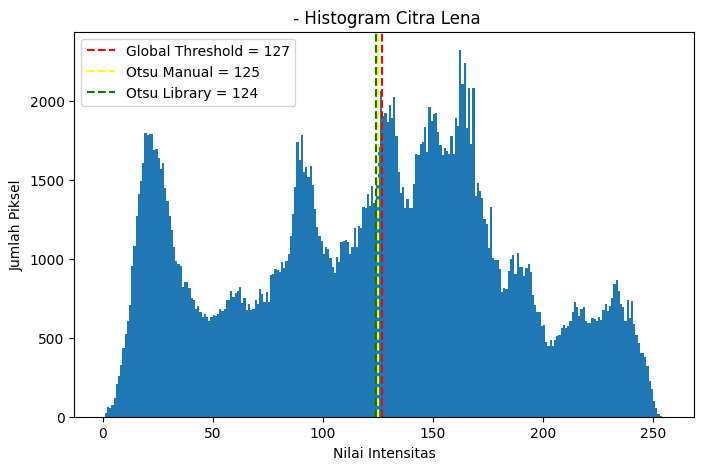

In [27]:
plt.figure(figsize=(8, 5))

plt.hist(blur.ravel(), bins=256, range=[0, 256])

plt.axvline(127, color='red', linestyle='--', label='Global Threshold = 127')
plt.axvline(125, color='yellow', linestyle='--', label='Otsu Manual = 125')
plt.axvline(124, color='green', linestyle='--', label='Otsu Library = 124')

plt.title(' - Histogram Citra Lena')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Piksel')
plt.legend()

plt.show()

## Nomor 5B Otsu vs Global Threshold pada KTP sendiri


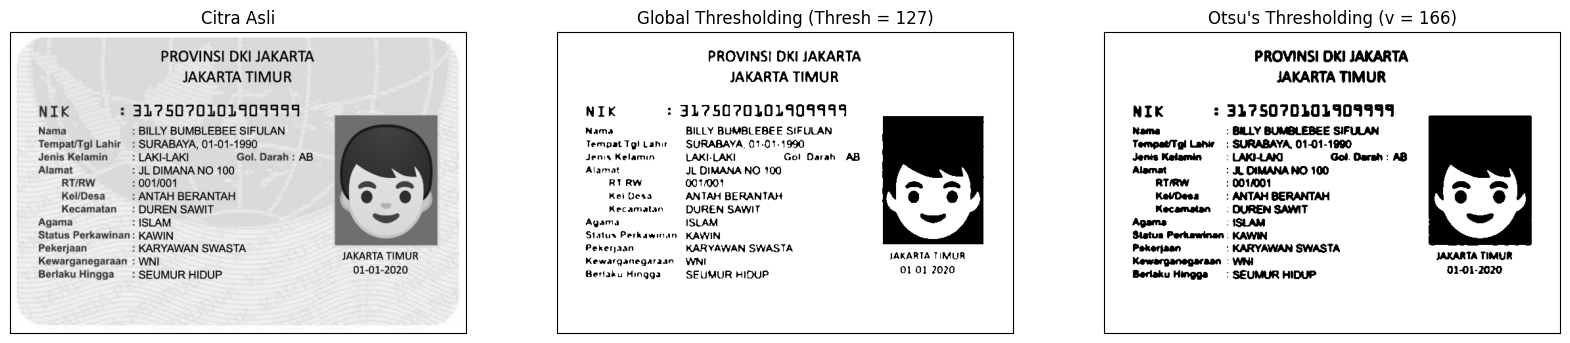

In [11]:
KTP_FILE = 'ktp_fulan.jpg'

ktp_gray = load_image(KTP_FILE, 0)
ktp_blur = cv.GaussianBlur(ktp_gray, (5,5), 0)

ktp_otsu, ktp_otsu_t = otsu(ktp_blur)                                   # Otsu manual
_, ktp_global = cv.threshold(ktp_blur, 127, 255, cv.THRESH_BINARY)      # Global 127

titles = ['Citra Asli', 'Global Thresholding (Thresh = 127)', "Otsu's Thresholding (v = " + str(ktp_otsu_t) + ")"]
citra = [ktp_gray, ktp_global, ktp_otsu]

plt.figure(figsize=(20,6))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(citra[i], 'gray', vmin=0, vmax=255)
    plt.title(titles[i]); plt.xticks([]), plt.yticks([])
plt.show()

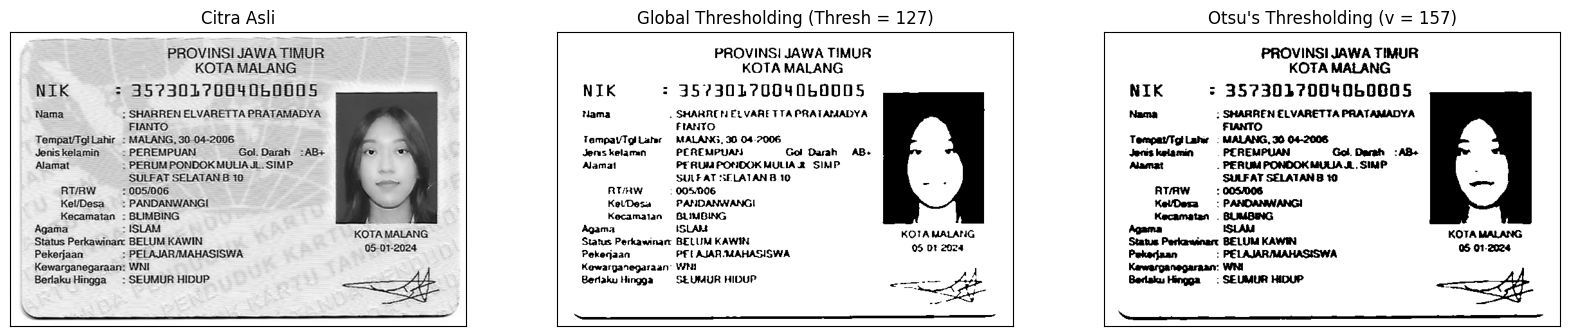

In [13]:
KTP_FILE = 'ktp kk.jpg'

ktp_gray = load_image(KTP_FILE, 0)
ktp_blur = cv.GaussianBlur(ktp_gray, (5,5), 0)

ktp_otsu, ktp_otsu_t = otsu(ktp_blur)                                   # Otsu manual
_, ktp_global = cv.threshold(ktp_blur, 127, 255, cv.THRESH_BINARY)      # Global 127

titles = ['Citra Asli', 'Global Thresholding (Thresh = 127)', "Otsu's Thresholding (v = " + str(ktp_otsu_t) + ")"]
citra = [ktp_gray, ktp_global, ktp_otsu]

plt.figure(figsize=(20,6))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(citra[i], 'gray', vmin=0, vmax=255)
    plt.title(titles[i]); plt.xticks([]), plt.yticks([])
plt.show()

**Analisis singkat:** pada KTP, latar kartu berwarna biru muda (intensitas grayscale tinggi) sedangkan teks gelap. Threshold global 127 bersifat tetap, sehingga hasilnya sangat bergantung pada terang-gelapnya foto. Otsu menghitung `T` dari histogram citra itu sendiri (di contoh modul sekitar 166), sehingga pemisahan teks dan latar menyesuaikan kondisi foto dan hasilnya biasanya lebih bersih. *(Bandingkan dengan hasil KTP Anda dan tuliskan pengamatan sendiri di sini.)*

## Nomor 6A Region Growing Manual (citra `data.coins()`)

Ukuran citra: (303, 384) | dtype: uint8
Seed koin  : (baris, kolom) = (36, 43) | intensitas = 159
Seed latar : (baris, kolom) = (150, 5) | intensitas = 80
Seed tepi  : (baris, kolom) = (36, 53) | intensitas = 128


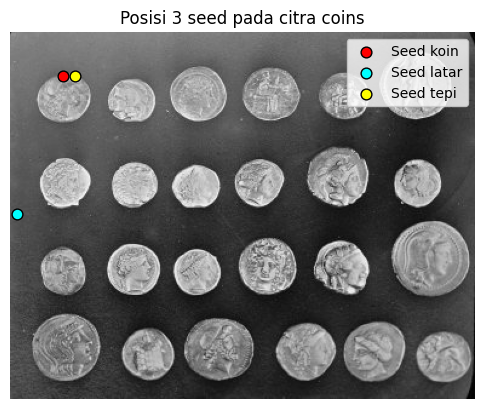

In [14]:
gray = data.coins()                 # grayscale, 303 x 384
print('Ukuran citra:', gray.shape, '| dtype:', gray.dtype)

def region_growing(gray, seed, T, ref='mean'):
    """
    Region growing 4-ketetanggaan.
    ref='mean' : bandingkan dengan rata-rata region yang terus diperbarui
    ref='seed' : bandingkan dengan intensitas seed (sama dengan skimage.flood)
    """
    H, W = gray.shape
    g = gray.astype(np.float64)
    mask = np.zeros((H, W), dtype=bool)

    r0, c0 = seed
    mask[r0, c0] = True
    jumlah, total = 1, g[r0, c0]
    seed_val = g[r0, c0]
    antrian = deque([(r0, c0)])
    tetangga = [(-1,0), (1,0), (0,-1), (0,1)]

    while antrian:
        y, x = antrian.popleft()
        for dy, dx in tetangga:
            ny, nx = y + dy, x + dx
            if 0 <= ny < H and 0 <= nx < W and not mask[ny, nx]:
                acuan = (total / jumlah) if ref == 'mean' else seed_val
                if abs(g[ny, nx] - acuan) <= T:
                    mask[ny, nx] = True
                    jumlah += 1
                    total += g[ny, nx]
                    antrian.append((ny, nx))
    return mask


# ---------- Penentuan 3 seed ----------
seed_koin = (36, 43)                                   # (baris, kolom) di dalam koin

# seed tepi: cari kolom dengan perubahan intensitas terbesar ke kanan dari seed koin
baris = seed_koin[0]
segmen = gray[baris, seed_koin[1]:seed_koin[1] + 30].astype(int)
kolom_tepi = seed_koin[1] + int(np.argmax(np.abs(np.diff(segmen)))) + 1
seed_tepi = (baris, kolom_tepi)

seed_latar = (150, 5)                                  # area latar (di luar koin)

seeds = {'Seed koin': seed_koin, 'Seed latar': seed_latar, 'Seed tepi': seed_tepi}
for nama, s in seeds.items():
    print(f'{nama:<11}: (baris, kolom) = {s} | intensitas = {gray[s]}')

# ---------- Tampilkan posisi seed ----------
plt.figure(figsize=(6,5))
plt.imshow(gray, 'gray')
warna = ['red', 'cyan', 'yellow']
for (nama, s), w in zip(seeds.items(), warna):
    plt.scatter(s[1], s[0], c=w, s=60, edgecolors='black', label=nama)
plt.legend(); plt.title('Posisi 3 seed pada citra coins'); plt.axis('off'); plt.show()

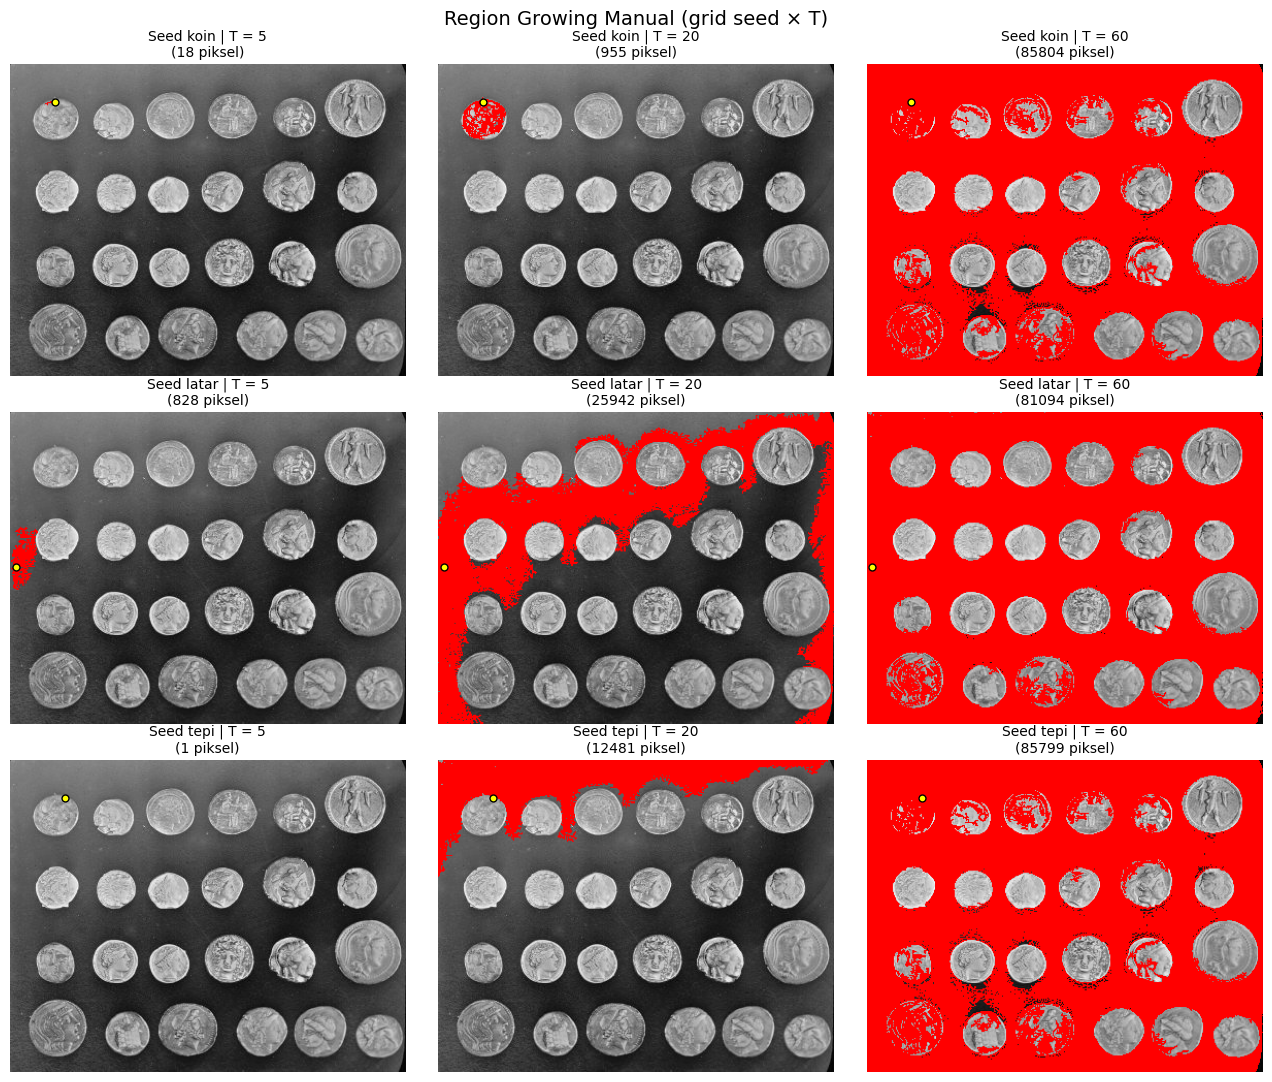

In [15]:
def overlay_mask(gray, mask):
    rgb = np.dstack([gray] * 3).copy()
    rgb[mask] = [255, 0, 0]                 # region berwarna merah
    return rgb

def tampilkan_grid(fungsi_region, judul):
    T_list = [5, 20, 60]
    fig, axes = plt.subplots(3, 3, figsize=(13, 11))
    for i, (nama, s) in enumerate(seeds.items()):
        for j, T in enumerate(T_list):
            mask = fungsi_region(s, T)
            ax = axes[i, j]
            ax.imshow(overlay_mask(gray, mask))
            ax.scatter(s[1], s[0], c='yellow', s=25, edgecolors='black')
            ax.set_title(f'{nama} | T = {T}\n({mask.sum()} piksel)', fontsize=10)
            ax.axis('off')
    fig.suptitle(judul, fontsize=14)
    plt.tight_layout(); plt.show()

tampilkan_grid(lambda s, T: region_growing(gray, s, T, ref='mean'),
               'Region Growing Manual (grid seed × T)')

**Pengamatan (cocokkan dengan hasil sendiri):**

- **Seed koin:** `T = 5` hanya menangkap bercak kecil karena tekstur koin bervariasi; `T = 20` menutupi satu koin; `T = 60` mulai "bocor" ke latar dan koin lain.
- **Seed latar:** `T` kecil hanya menangkap sebagian latar; `T = 60` bisa menyebar hampir ke seluruh citra karena latar dan koin intensitasnya cukup dekat.
- **Seed tepi:** hasil paling tidak stabil. Intensitas tepi berada di antara koin dan latar, sehingga region cepat bocor ke salah satu sisi.
- Kesimpulan: region growing **sangat bergantung pada posisi seed dan nilai T**. T terlalu kecil menyebabkan under-growing (banyak region kecil), T terlalu besar menyebabkan bocor (over-merging).

## Nomor 6B Region Growing

Contoh seed (121, 63), tolerance=20 -> 177 piksel


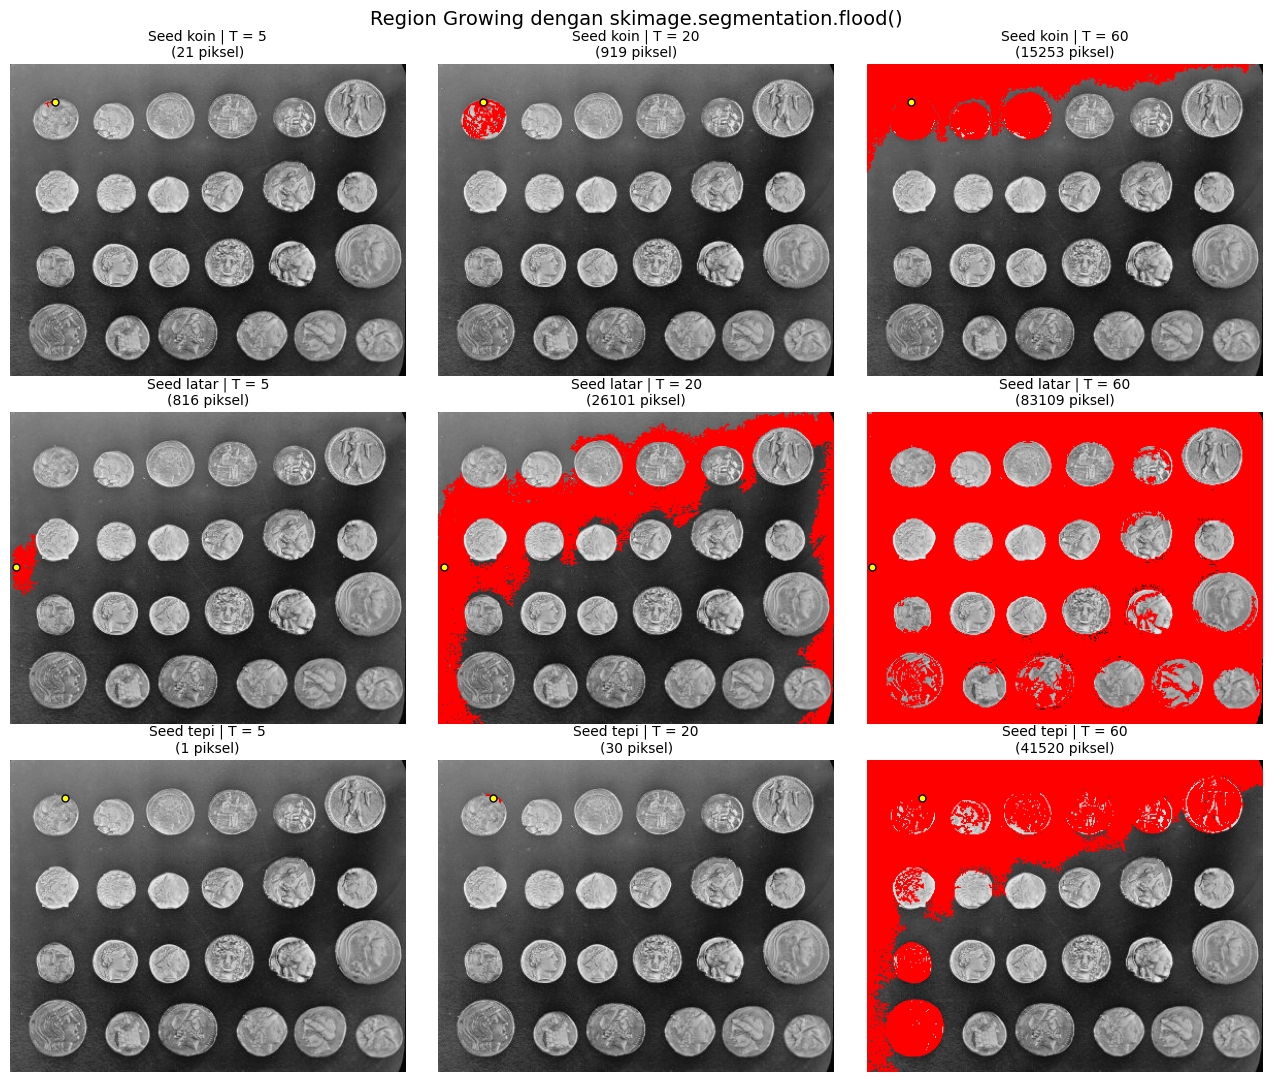

Seed          T    Manual(ref=seed)   flood()   Beda piksel
Seed koin     5                  21        21             0
Seed koin    20                 919       919             0
Seed koin    60               15253     15253             0
Seed latar    5                 816       816             0
Seed latar   20               26101     26101             0
Seed latar   60               83109     83109             0
Seed tepi     5                   1         1             0
Seed tepi    20                  30        30             0
Seed tepi    60               41520     41520             0


In [16]:
# Contoh dasar sesuai modul
seed = (121, 63)                              # (baris, kolom)
region = flood(
    gray,
    seed_point=seed,
    tolerance=20,
    connectivity=1                            # 4 tetangga untuk citra 2D
)
print('Contoh seed (121, 63), tolerance=20 ->', region.sum(), 'piksel')

# Grid 3 x 3 (seed × T)
tampilkan_grid(lambda s, T: flood(gray, seed_point=s, tolerance=T, connectivity=1),
               'Region Growing dengan skimage.segmentation.flood()')

# Perbandingan jumlah piksel: manual (acuan seed) vs flood
print(f"{'Seed':<11}{'T':>4}{'Manual(ref=seed)':>20}{'flood()':>10}{'Beda piksel':>14}")
for nama, s in seeds.items():
    for T in [5, 20, 60]:
        m = region_growing(gray, s, T, ref='seed')
        f = flood(gray, seed_point=s, tolerance=T, connectivity=1)
        print(f'{nama:<11}{T:>4}{m.sum():>20}{f.sum():>10}{int((m != f).sum()):>14}')

**Catatan:** versi manual dengan `ref='seed'` (membandingkan ke intensitas seed) menghasilkan mask yang sama dengan `flood()`. Pada 6A dipakai `ref='mean'` (rata-rata region yang diperbarui terus), sehingga jumlah pikselnya bisa berbeda dari `flood()`.

## Nomor 7 Segmentasi Warna KTP: Tampilkan Hanya Warna Biru

Piksel biru: 249795 dari 324722 (76.9%)


,Cluster,RGB centroid,HSV centroid,Jumlah piksel,Termasuk biru?
0,0,"(179, 187, 189)","(96, 13, 189)",21090,False
1,1,"(60, 70, 77)","(102, 56, 77)",16523,True
2,2,"(202, 239, 247)","(95, 46, 247)",125561,True
3,3,"(116, 132, 139)","(99, 42, 139)",12372,True
4,4,"(247, 252, 252)","(90, 5, 252)",39020,False
5,5,"(5, 92, 141)","(101, 246, 141)",10126,True
6,6,"(16, 22, 29)","(106, 114, 29)",14817,False
7,7,"(163, 222, 243)","(98, 84, 243)",85213,True


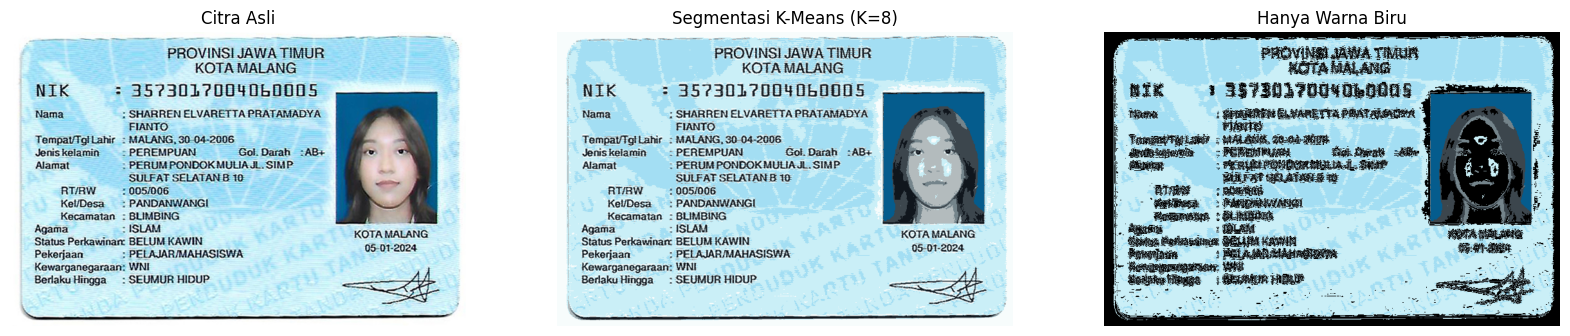

In [17]:
img_bgr = load_image(KTP_FILE)                       # KTP_FILE didefinisikan di nomor 5B
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

# ---- K-Means (K = 8)
K = 8
Z = img_rgb.reshape((-1, 3)).astype(np.float32)
rng = np.random.default_rng(42)
idx = rng.choice(len(Z), size=min(50000, len(Z)), replace=False)

kmeans = KMeans(n_clusters=K, n_init=10, random_state=42).fit(Z[idx])
labels = kmeans.predict(Z)
centers = np.uint8(kmeans.cluster_centers_)

segmented = centers[labels].reshape(img_rgb.shape)

# ---- Konversi ke HSV (OpenCV: H 0-179, S & V 0-255)
hsv = cv.cvtColor(segmented, cv.COLOR_RGB2HSV)
H, S, V = hsv[..., 0], hsv[..., 1], hsv[..., 2]

kelompok_biru = np.where((H >= 85) & (H <= 130) & (S >= 25) & (V >= 40))   # indeks piksel biru
mask_biru = np.zeros(H.shape, dtype=bool)
mask_biru[kelompok_biru] = True

hanya_biru = np.zeros_like(segmented)                 # latar hitam
hanya_biru[mask_biru] = segmented[mask_biru]

print(f'Piksel biru: {mask_biru.sum()} dari {mask_biru.size} ({100*mask_biru.mean():.1f}%)')

# ---- Ringkasan 8 cluster
cent_hsv = cv.cvtColor(centers.reshape(1, -1, 3), cv.COLOR_RGB2HSV).reshape(-1, 3)
tabel = pd.DataFrame({
    'Cluster': range(K),
    'RGB centroid': [tuple(int(v) for v in c) for c in centers],
    'HSV centroid': [tuple(int(v) for v in c) for c in cent_hsv],
    'Jumlah piksel': np.bincount(labels, minlength=K),
})
tabel['Termasuk biru?'] = [(85 <= h <= 130) and (s >= 25) and (v >= 40) for h, s, v in cent_hsv]
display(tabel)

# ---- Tampilkan
titles = ['Citra Asli', f'Segmentasi K-Means (K={K})', 'Hanya Warna Biru']
citra = [img_rgb, segmented, hanya_biru]
plt.figure(figsize=(20,5))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(citra[i]); plt.title(titles[i]); plt.axis('off')
plt.show()

Piksel biru: 247546 dari 317852 (77.9%)


,Cluster,RGB centroid,HSV centroid,Jumlah piksel,Termasuk biru?
0,0,"(135, 147, 155)","(102, 33, 155)",9320,True
1,1,"(218, 239, 248)","(99, 31, 248)",122781,True
2,2,"(15, 16, 17)","(105, 30, 17)",8469,False
3,3,"(215, 70, 51)","(3, 195, 215)",10914,False
4,4,"(195, 224, 244)","(102, 51, 244)",115445,True
5,5,"(239, 210, 172)","(17, 71, 239)",8831,False
6,6,"(252, 254, 254)","(90, 2, 254)",25231,False
7,7,"(59, 60, 63)","(113, 16, 63)",16861,False


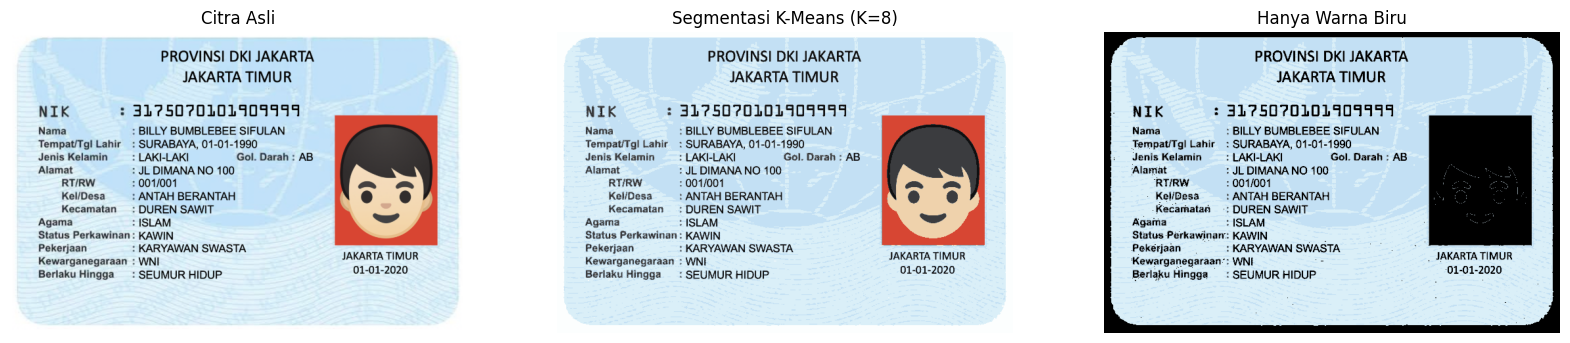

In [30]:
KTP_FILE = 'ktp_fulan.jpg'

# ---- Baca gambar KTP Fulan dari folder PCVK IMAGES
img_bgr = cv.imread(os.path.join(BASE, KTP_FILE))
if img_bgr is None:
    raise FileNotFoundError(f"{KTP_FILE} tidak ditemukan di {BASE}")
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

# ---- K-Means (K = 8)
K = 8
Z = img_rgb.reshape((-1, 3)).astype(np.float32)
rng = np.random.default_rng(42)
idx = rng.choice(len(Z), size=min(50000, len(Z)), replace=False)

kmeans = KMeans(n_clusters=K, n_init=10, random_state=42).fit(Z[idx])
labels = kmeans.predict(Z)
centers = np.uint8(kmeans.cluster_centers_)

segmented = centers[labels].reshape(img_rgb.shape)

# ---- Konversi ke HSV (OpenCV: H 0-179, S & V 0-255)
hsv = cv.cvtColor(segmented, cv.COLOR_RGB2HSV)
H, S, V = hsv[..., 0], hsv[..., 1], hsv[..., 2]

kelompok_biru = np.where((H >= 85) & (H <= 130) & (S >= 25) & (V >= 40))   # indeks piksel biru
mask_biru = np.zeros(H.shape, dtype=bool)
mask_biru[kelompok_biru] = True

hanya_biru = np.zeros_like(segmented)                 # latar hitam
hanya_biru[mask_biru] = segmented[mask_biru]

print(f'Piksel biru: {mask_biru.sum()} dari {mask_biru.size} ({100*mask_biru.mean():.1f}%)')

# ---- Ringkasan 8 cluster
cent_hsv = cv.cvtColor(centers.reshape(1, -1, 3), cv.COLOR_RGB2HSV).reshape(-1, 3)
tabel = pd.DataFrame({
    'Cluster': range(K),
    'RGB centroid': [tuple(int(v) for v in c) for c in centers],
    'HSV centroid': [tuple(int(v) for v in c) for c in cent_hsv],
    'Jumlah piksel': np.bincount(labels, minlength=K),
})
tabel['Termasuk biru?'] = [(85 <= h <= 130) and (s >= 25) and (v >= 40) for h, s, v in cent_hsv]
display(tabel)

# ---- Tampilkan
titles = ['Citra Asli', f'Segmentasi K-Means (K={K})', 'Hanya Warna Biru']
citra = [img_rgb, segmented, hanya_biru]
plt.figure(figsize=(20,5))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(citra[i]); plt.title(titles[i]); plt.axis('off')
plt.show()

---
# D2. TUGAS KELOMPOK

In [18]:
!apt-get -qq update
!apt-get -qq install tesseract-ocr tesseract-ocr-ind
!pip -q install pytesseract

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package tesseract-ocr-ind.
(Reading database ... 122815 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-ind_1%3a4.1.0-2_all.deb ...
Unpacking tesseract-ocr-ind (1:4.1.0-2) ...
Setting up tesseract-ocr-ind (1:4.1.0-2) ...


Ukuran citra : (904, 1400) | Threshold Otsu = 145.0


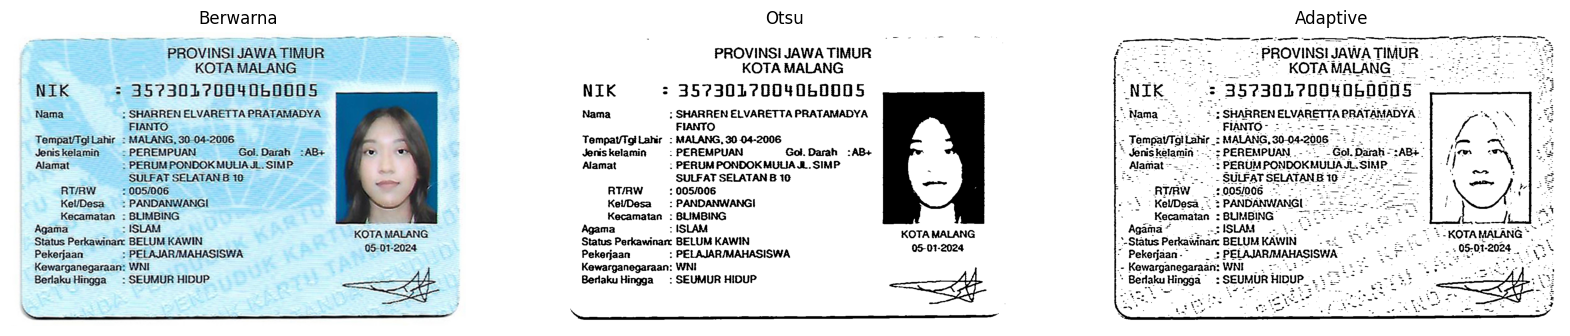

In [32]:
import re, difflib
import pytesseract
from pytesseract import Output

KTP_FILE_KELOMPOK = 'ktp kk.jpg'             # KTP kelompok (di folder PCVK IMAGES)

# --- Pengaturan OCR (dibuat SAMA untuk ketiga citra)
LANG = 'ind'                                 # model bahasa Indonesia
CONFIG = '--psm 6'                           # asumsi satu blok teks seragam
CONF_MIN = 60                                # batas confidence untuk kotak hijau

# --- Baca & samakan ukuran
asli_bgr = load_image(KTP_FILE_KELOMPOK)
LEBAR = 1400
skala = LEBAR / asli_bgr.shape[1]
asli_bgr = cv.resize(asli_bgr, (LEBAR, int(asli_bgr.shape[0] * skala)), interpolation=cv.INTER_CUBIC)

img_warna = cv.cvtColor(asli_bgr, cv.COLOR_BGR2RGB)          # 1) berwarna asli
gray_k    = cv.cvtColor(asli_bgr, cv.COLOR_BGR2GRAY)
blur_k    = cv.GaussianBlur(gray_k, (3,3), 0)

t_otsu, img_otsu = cv.threshold(blur_k, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)   # 2) Otsu
img_adaptive = cv.adaptiveThreshold(blur_k, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv.THRESH_BINARY, 31, 10)                        # 3) Adaptive

print('Ukuran citra :', img_warna.shape[:2], '| Threshold Otsu =', t_otsu)

inputs = {'Berwarna': img_warna, 'Otsu': img_otsu, 'Adaptive': img_adaptive}

plt.figure(figsize=(20,5))
for i, (nama, im) in enumerate(inputs.items()):
    plt.subplot(1,3,i+1)
    plt.imshow(im, None if im.ndim == 3 else 'gray')
    plt.title(nama); plt.axis('off')
plt.show()

In [33]:
hasil_teks = {}
for nama, im in inputs.items():
    hasil_teks[nama] = pytesseract.image_to_string(im, lang=LANG, config=CONFIG)
    print('=' * 10, nama.upper(), '=' * 10)
    print(hasil_teks[nama].strip())
    print()

========== BERWARNA ==========
PROVINSI JAWA TIMUR
KOTAMALANG - :
NIK : 357301700105D005
Nama : SHARREN ELVARETTA PRATAMADYA
FIANTO
Tempat/TgiLahir : MALANG, 30-04-2006
Jeniskelamin — - PEREMPUAN Gol. Darah :ABx n
Alamat : PERUMPONDOK MUA JL. SIMP
SULFAT SELATANB:10 j
RTRW — :005/006 AI
Kel/Desa — : PANDANWANGI Nan
Kecamatan : BLIMBING ja,
Agama : ISLAM :
Status Perkawinan: BELUM KAWIN IA Tn
Pekerjaan » PELAJAR/MAHASISWA :
Kewarganegaraan: WNI
BerlakuHingga : SEUMUR HIDUP ——&
NE Em

========== OTSU ==========
PROVINSI JAWA TIMUR
KOTA MALANG
NIK : 3573017001059005
Nama : SHARREN ELVARETTA PRATAMADYA
FIANTO
Tempat/TgiLahir : MALANG, 3004-2006
Jeniskelamin — : PEREMPUAN Gol. Darah :ABx
Alamat . PERUM PONDOK MULIA JL. SIMP
SULFAT SELATANB 10
RTIAW ——:005/006 '
Ke/Desa : PANDANWANGI
Kecamatan : BLIMBING
Agama : ISLAM
Status Perkawinarc BELUM KAWIN KOTA MALANG
Pekerjaan - PELAJAR/MAHASISWA 05-01-2024
Kewarganegaraan: WNI
Berlaku Hingga: SEUMUR HIDUP —
IN

========== ADAPTIVE ==========
POT P

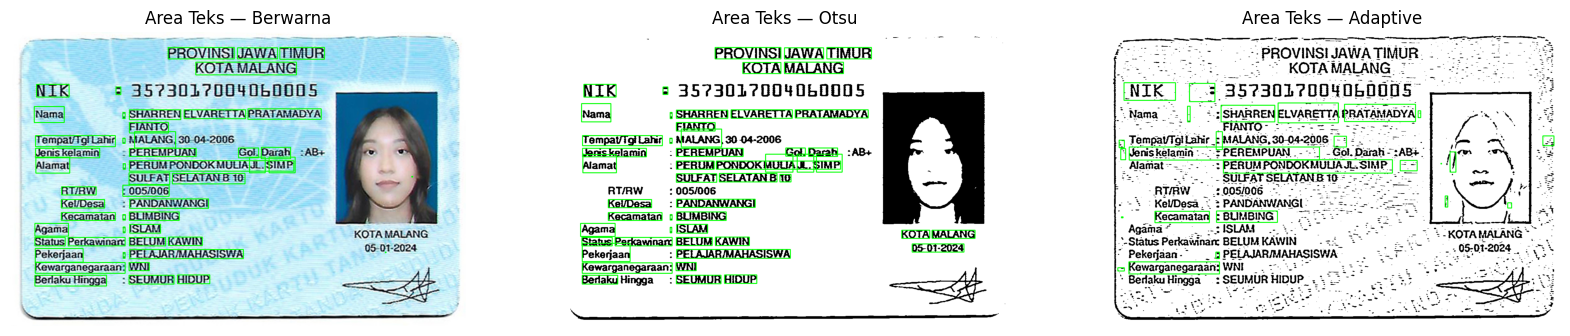

In [34]:
def ocr_data(im):
    return pytesseract.image_to_data(im, lang=LANG, config=CONFIG, output_type=Output.DICT)

def gambar_kotak(im, data, conf_min=CONF_MIN):
    kanvas = im.copy() if im.ndim == 3 else cv.cvtColor(im, cv.COLOR_GRAY2RGB)
    for i in range(len(data['text'])):
        teks = data['text'][i].strip()
        conf = float(data['conf'][i])
        if teks and conf > conf_min:
            x, y, w, h = data['left'][i], data['top'][i], data['width'][i], data['height'][i]
            cv.rectangle(kanvas, (x, y), (x + w, y + h), (0, 255, 0), 2)
    return kanvas

data_ocr = {nama: ocr_data(im) for nama, im in inputs.items()}

plt.figure(figsize=(20,6))
for i, (nama, im) in enumerate(inputs.items()):
    plt.subplot(1,3,i+1)
    plt.imshow(gambar_kotak(im, data_ocr[nama]))
    plt.title(f'Area Teks — {nama}'); plt.axis('off')
plt.show()

In [44]:
ACUAN = ['PROVINSI', 'MALANG', 'SHARREN', 'ELVARETTA', 'PRATAMADYA',
         'PEREMPUAN', 'PANDANWANGI', 'BLIMBING', 'ISLAM', 'SEUMUR HIDUP']
assert len(ACUAN) == 10, 'Harus tepat 10 item acuan'

# Ubah ACUAN menjadi format yang dipakai evaluate_ocr()
reference_items = [{"No": i, "Acuan": kata} for i, kata in enumerate(ACUAN, start=1)]


def normalisasi(teks):
    """Huruf besar, buang tanda baca, rapikan spasi."""
    teks = teks.upper()
    teks = re.sub(r'[^A-Z0-9 \n]', '', teks)
    return ' '.join(teks.split())


def ada_di_teks(target, teks_bersih):
    """Cek target ada sebagai kata utuh (bukan potongan di tengah kata lain)."""
    pola = r'(?<![A-Z0-9])' + re.escape(target) + r'(?![A-Z0-9])'
    return re.search(pola, teks_bersih) is not None


def evaluate_ocr(items, raw_text):
    results = []
    clean_text = normalisasi(raw_text)

    for item in items:
        target = normalisasi(item["Acuan"])

        if ada_di_teks(target, clean_text):
            match = True
            extracted = item["Acuan"].upper()
        else:
            match = False
            # Bagian acuan yang masih berhasil terbaca
            matched_words = [p for p in target.split() if ada_di_teks(p, clean_text)]
            extracted = (" ".join(matched_words) + "  ✗") if matched_words else "(tidak cocok)  ✗"

        results.append({"extracted": extracted, "match": match})

    return results


# Membandingkan 10 teks acuan dengan ketiga hasil OCR
res_color    = evaluate_ocr(reference_items, hasil_teks['Berwarna'])
res_otsu     = evaluate_ocr(reference_items, hasil_teks['Otsu'])
res_adaptive = evaluate_ocr(reference_items, hasil_teks['Adaptive'])

# Jumlah item cocok (dipakai oleh sel ringkasan Langkah 5)
cocok = {
    'Berwarna': sum(r['match'] for r in res_color),
    'Otsu':     sum(r['match'] for r in res_otsu),
    'Adaptive': sum(r['match'] for r in res_adaptive),
}

df_table_items = pd.DataFrame({
    'No': [it['No'] for it in reference_items],
    'Teks Sebenarnya': [it['Acuan'] for it in reference_items],
    'OCR Citra Berwarna': [r['extracted'] for r in res_color],
    'OCR Otsu': [r['extracted'] for r in res_otsu],
    'OCR Adaptive': [r['extracted'] for r in res_adaptive],
})

try:
    display(df_table_items.style.hide(axis="index"))
except Exception:
    display(df_table_items)


No,Teks Sebenarnya,OCR Citra Berwarna,OCR Otsu,OCR Adaptive
1,PROVINSI,PROVINSI,PROVINSI,(tidak cocok) ✗
2,MALANG,MALANG,MALANG,MALANG
3,SHARREN,SHARREN,SHARREN,SHARREN
4,ELVARETTA,ELVARETTA,ELVARETTA,ELVARETTA
5,PRATAMADYA,PRATAMADYA,PRATAMADYA,PRATAMADYA
6,PEREMPUAN,PEREMPUAN,PEREMPUAN,PEREMPUAN
7,PANDANWANGI,PANDANWANGI,PANDANWANGI,PANDANWANGI
8,BLIMBING,BLIMBING,BLIMBING,(tidak cocok) ✗
9,ISLAM,ISLAM,ISLAM,ISLAM
10,SEUMUR HIDUP,SEUMUR HIDUP,SEUMUR HIDUP,SEUMUR HIDUP


In [38]:
ringkasan = pd.DataFrame({
    'Citra masukan OCR': ['Berwarna asli', 'Segmentasi Otsu', 'Segmentasi Adaptive'],
    'Item terbaca tepat': [cocok['Berwarna'], cocok['Otsu'], cocok['Adaptive']],
    'Kecocokan (%)': [cocok[n] / 10 * 100 for n in inputs],
    'Rata-rata confidence': [round(rata_confidence(data_ocr[n]), 2) for n in inputs],
})
display(ringkasan)

# Bantuan untuk menjawab pertanyaan analisis
terbaik_cocok = ringkasan.loc[ringkasan['Kecocokan (%)'].idxmax(), 'Citra masukan OCR']
terbaik_conf  = ringkasan.loc[ringkasan['Rata-rata confidence'].idxmax(), 'Citra masukan OCR']
print('Kecocokan tertinggi        :', terbaik_cocok)
print('Confidence rata-rata tertinggi:', terbaik_conf)
print('Apakah sama?               :', 'YA' if terbaik_cocok == terbaik_conf else 'TIDAK')

,Citra masukan OCR,Item terbaca tepat,Kecocokan (%),Rata-rata confidence
0,Berwarna asli,10,100.0,67.53
1,Segmentasi Otsu,10,100.0,77.63
2,Segmentasi Adaptive,8,80.0,30.49


Kecocokan tertinggi        : Berwarna asli
Confidence rata-rata tertinggi: Segmentasi Otsu
Apakah sama?               : TIDAK


In [42]:
def hitung_average_confidence(image):
    data_ocr = pytesseract.image_to_data(
        image,
        lang=LANG,                 # 'ind', sama dengan pengaturan OCR sebelumnya
        config=CONFIG,             # '--psm 6'
        output_type=pytesseract.Output.DICT
    )

    confidence = []

    for teks, conf in zip(data_ocr['text'], data_ocr['conf']):
        conf = float(conf)

        # Ambil confidence yang valid: kata tidak kosong dan conf >= 0
        if teks.strip() and conf >= 0:
            confidence.append(conf)

    return float(np.mean(confidence)) if confidence else 0.0


confidence_asli     = hitung_average_confidence(img_warna)
confidence_otsu     = hitung_average_confidence(img_otsu)
confidence_adaptive = hitung_average_confidence(img_adaptive)


print("=== AVERAGE CONFIDENCE ===")
print(f"Citra Berwarna : {confidence_asli:.2f}")
print(f"Otsu           : {confidence_otsu:.2f}")
print(f"Adaptive       : {confidence_adaptive:.2f}")

=== AVERAGE CONFIDENCE ===
Citra Berwarna : 67.53
Otsu           : 77.63
Adaptive       : 30.49


## Pertanyaan Analisis

**Ringkasan hasil percobaan**

| Citra masukan OCR | Item terbaca tepat | Kecocokan (%) | Rata-rata confidence |
|---|---|---|---|
| Berwarna asli | 10 | 100% | 67,53 |
| Segmentasi Otsu (T = 145) | 10 | 100% | 77,63 |
| Segmentasi Adaptive | 8 | 80% | 30,49 |


---


### 1. Citra masukan mana yang menghasilkan pembacaan paling tepat? Tunjukkan buktinya dari tabel.

Citra **berwarna asli** dan **Otsu** sama-sama menghasilkan pembacaan paling tepat, yaitu **10 dari 10 item (kecocokan 100%)**, sedangkan citra **Adaptive** hanya **8 dari 10 item (80%)**. Berwarna dan Otsu seri pada kecocokan, tetapi Otsu lebih unggul pada rata-rata confidence (**77,63** dibanding **67,53**) dan teks hasil OCR-nya lebih sedikit mengandung karakter sampah. Dengan demikian, Otsu adalah masukan terbaik secara keseluruhan, sedangkan Adaptive paling buruk karena kecocokan dan confidence-nya sama-sama terendah (**30,49**).

---

### 2. Sebutkan minimal dua kesalahan pembacaan.

| Citra | Teks sebenarnya | Hasil OCR | Jenis kesalahan |
|---|---|---|---|
| Adaptive | PROVINSI JAWA TIMUR | `POT Pn PROVINSIJAWATIMUR.` | Spasi hilang sehingga kata menyatu, ada karakter sampah di depan |
| Adaptive | BLIMBING | `BUMBING` | Huruf tertukar (`L` terbaca `U`) |
| Berwarna | NIK (angka `9`) | `357301700105D005` | Angka terbaca sebagai huruf `D` |
| Adaptive | NIK | `3573017004D650005` | Angka salah dan jumlah digit bertambah |
| Otsu | 30-04-2006 | `3004-2006` | Tanda hubung pada tanggal hilang |
| Otsu | Perkawinan | `Perkawinarc` | Huruf `n` terbaca `rc` |
| Berwarna | PERUM PONDOK MULIA | `PERUMPONDOK MUA` | Spasi hilang dan huruf `LI` hilang |
| Adaptive | Alamat | `Aamat` | Huruf `l` hilang |

---

### 3. Apakah segmentasi selalu meningkatkan ketepatan OCR? Jelaskan berdasarkan hasil percobaan.

**Tidak selalu.** Segmentasi **Otsu** tidak menaikkan kecocokan (tetap 100%, sama dengan citra berwarna), tetapi menaikkan rata-rata confidence sekitar 10 poin (67,53 menjadi 77,63) dan menghasilkan teks yang lebih bersih. Segmentasi **Adaptive** justru **menurunkan** kualitas: kecocokan turun dari 100% menjadi 80% dan confidence turun drastis menjadi 30,49. Ambang lokal pada Adaptive (ukuran blok 31, C = 10) ikut menangkap pola halus pada latar KTP dan membuat goresan huruf yang tipis menjadi terputus. Otsu bekerja baik karena teks yang gelap dan latar kartu yang terang sudah cukup kontras untuk dipisahkan dengan satu ambang global (T = 145). Jadi, keberhasilan segmentasi bergantung pada metode dan parameter yang dipakai.

---

### 4. Bagaimana warna atau pola latar belakang memengaruhi pembacaan teks?

Latar KTP yang berwarna biru muda dengan pola garis halus, watermark, dan foto menurunkan kontras antara teks dan latar. Dampaknya terlihat pada citra berwarna, yaitu muncul karakter sampah seperti `ja,`, `Nan`, `IA Tn`, dan `NE Em`, serta angka NIK yang salah baca (`D`). Pada citra Adaptive, pola latar dianggap sebagai objek sehingga muncul banyak simbol sampah (`£—`, `—————`, `Nusa`, `Tale NY T-`) dan confidence menurun tajam. Sebaliknya, ketika latar berhasil dihilangkan seperti pada Otsu, teks tampil hitam di atas putih yang lebih jelas dan sampahnya jauh berkurang. Meski begitu, elemen non-teks tetap bisa ikut terbaca, misalnya `KOTA MALANG 05-01-2024` pada hasil Otsu yang kemungkinan berasal dari tempat dan tanggal penerbitan di bagian bawah kartu.

---

### 5. Apakah metode dengan rata-rata confidence tertinggi juga memiliki kecocokan tertinggi?

Pada percobaan ini **ya, tetapi tidak sepenuhnya**. **Otsu** memiliki confidence tertinggi (77,63) dan kecocokannya juga tertinggi (100%), namun kecocokan itu **seri** dengan citra berwarna yang confidence-nya lebih rendah (67,53). Karena seri, keluaran "Apakah sama?" pada notebook menampilkan *TIDAK*, sebab program hanya memilih nilai pertama (Berwarna). **Adaptive** konsisten: confidence terendah (30,49) dan kecocokan terendah (80%).

Kesimpulannya, confidence hanyalah tingkat keyakinan internal Tesseract, bukan ukuran kebenaran hasil. Kecocokan hanya diukur dari 10 item acuan sehingga mudah mencapai 100% dan tidak dapat membedakan Berwarna dari Otsu, sedangkan confidence dihitung dari seluruh kata yang terdeteksi, termasuk kata sampah. Karena itu, confidence tertinggi tidak otomatis menjamin kecocokan tertinggi, dan keduanya sebaiknya dipakai bersama.